In [1]:
import sys
sys.path.insert(0, r"C:\Users\setor\matplotlib_fresh")
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
df = pd.read_csv("iphone.csv", encoding="latin-1")
print(df.head())

  productAsin country        date  isVerified  ratingScore  \
0  B09G9BL5CP   India  11-08-2024        True            4   
1  B09G9BL5CP   India  16-08-2024        True            5   
2  B09G9BL5CP   India  14-05-2024        True            4   
3  B09G9BL5CP   India  24-06-2024        True            5   
4  B09G9BL5CP   India  18-05-2024        True            5   

               reviewTitle                                  reviewDescription  \
0               No charger  Every thing is good about iPhones, there's not...   
1          iPhone 13 256GB  It look so fabulous, I am android user switche...   
2  Flip camera option nill  I tried to flip camera while recording but no ...   
3                  Product                                       100% genuine   
4             Good product         Happy to get the iPhone 13 in Amazon offer   

                                           reviewUrl  \
0  https://www.amazon.in/gp/customer-reviews/R345...   
1  https://www.amazon.in/gp/

In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (3062, 11)


In [6]:
print("Column names:")
print(df.columns)

Column names:
Index(['productAsin', 'country', 'date', 'isVerified', 'ratingScore',
       'reviewTitle', 'reviewDescription', 'reviewUrl', 'reviewedIn',
       'variant', 'variantAsin'],
      dtype='str')


In [7]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  productAsin country        date  isVerified  ratingScore  \
0  B09G9BL5CP   India  11-08-2024        True            4   
1  B09G9BL5CP   India  16-08-2024        True            5   
2  B09G9BL5CP   India  14-05-2024        True            4   
3  B09G9BL5CP   India  24-06-2024        True            5   
4  B09G9BL5CP   India  18-05-2024        True            5   

               reviewTitle                                  reviewDescription  \
0               No charger  Every thing is good about iPhones, there's not...   
1          iPhone 13 256GB  It look so fabulous, I am android user switche...   
2  Flip camera option nill  I tried to flip camera while recording but no ...   
3                  Product                                       100% genuine   
4             Good product         Happy to get the iPhone 13 in Amazon offer   

                                           reviewUrl  \
0  https://www.amazon.in/gp/customer-reviews/R345...   
1  https://www

In [8]:
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
     productAsin country        date  isVerified  ratingScore  \
3057  B09G9D8KRQ   India  11-10-2023        True            1   
3058  B09G9D8KRQ   India  14-10-2022        True            2   
3059  B09G9D8KRQ   India  24-02-2022        True            3   
3060  B09G9D8KRQ   India  16-10-2023        True            1   
3061  B09G9D8KRQ   India  11-11-2023        True            1   

                              reviewTitle  \
3057  Very bad experience with i phone 13   
3058    not happy with this apple product   
3059                           Good phone   
3060                    Battery discharge   
3061    Batter power needs to be improved   

                                      reviewDescription  \
3057  Useless phon never buy this heat n useless cam...   
3058  iam not happy with this product why because ch...   
3059                                         Good phone   
3060  While charging mobile it's getting so hot even...   
3061  Battery power is be very

In [9]:
print("Data types:")
print(df.dtypes)

Data types:
productAsin            str
country                str
date                   str
isVerified            bool
ratingScore          int64
reviewTitle            str
reviewDescription      str
reviewUrl              str
reviewedIn             str
variant                str
variantAsin            str
dtype: object


In [10]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productAsin        3062 non-null   str  
 1   country            3062 non-null   str  
 2   date               3062 non-null   str  
 3   isVerified         3062 non-null   bool 
 4   ratingScore        3062 non-null   int64
 5   reviewTitle        3062 non-null   str  
 6   reviewDescription  2976 non-null   str  
 7   reviewUrl          3046 non-null   str  
 8   reviewedIn         3062 non-null   str  
 9   variant            3062 non-null   str  
 10  variantAsin        3062 non-null   str  
dtypes: bool(1), int64(1), str(9)
memory usage: 242.3 KB
None


In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
productAsin           0
country               0
date                  0
isVerified            0
ratingScore           0
reviewTitle           0
reviewDescription    86
reviewUrl            16
reviewedIn            0
variant               0
variantAsin           0
dtype: int64


In [12]:
print("Summary statistics:")
print(df.describe())

Summary statistics:
       ratingScore
count  3062.000000
mean      3.758981
std       1.579033
min       1.000000
25%       3.000000
50%       5.000000
75%       5.000000
max       5.000000


In [13]:
stop_words = set([
    'a','an','the','and','or','is','it','this','that','to','for','of','in','on','with',
    'as','its','at','from','by','be','are','was','were','but','i','my','me','you','your',
    'so','if','they','we','he','she','them','us'
])

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  # convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = ' '.join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

df['review_text'] = df['reviewTitle'].fillna('') + ' ' + df['reviewDescription'].fillna('')
df['cleaned_text'] = df['review_text'].apply(clean_text)
print("\nCleaned Data (First 10 Rows):")
print(df[['review_text', 'cleaned_text']].head(10))


Cleaned Data (First 10 Rows):
                                         review_text  \
0  No charger Every thing is good about iPhones, ...   
1  iPhone 13 256GB It look so fabulous, I am andr...   
2  Flip camera option nill I tried to flip camera...   
3                               Product 100% genuine   
4  Good product Happy to get the iPhone 13 in Ama...   
5    Too smooth and effective battery life 5 star ??   
6  Apple 13 256 GB Great Product... Nothing to sa...   
7                             Good Good product ????   
8                                  Good Nice product   
9                        Excellent Excellent product   

                                        cleaned_text  
0  no charger every thing good about iphones ther...  
1  iphone 13 256gb look fabulous am android user ...  
2  flip camera option nill tried flip camera whil...  
3                                product 100 genuine  
4      good product happy get iphone 13 amazon offer  
5           too smooth

In [14]:
df = df[["ratingScore", "reviewDescription"]]
df = df.dropna()
df.head()

,ratingScore,reviewDescription
0,4,"Every thing is good about iPhones, there's not..."
1,5,"It look so fabulous, I am android user switche..."
2,4,I tried to flip camera while recording but no ...
3,5,100% genuine
4,5,Happy to get the iPhone 13 in Amazon offer


In [15]:
print("Dataset shape:", df.shape)

Dataset shape: (2976, 2)


In [16]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df["label"] = df["ratingScore"].apply(get_sentiment)
df.head()

,ratingScore,reviewDescription,label
0,4,"Every thing is good about iPhones, there's not...",positive
1,5,"It look so fabulous, I am android user switche...",positive
2,4,I tried to flip camera while recording but no ...,positive
3,5,100% genuine,positive
4,5,Happy to get the iPhone 13 in Amazon offer,positive


In [17]:
df["label"].value_counts()

label
positive    1994
negative     747
neutral      235
Name: count, dtype: int64

In [18]:
df = df[df["label"] != "neutral"].copy()
df["label"].value_counts()

label
positive    1994
negative     747
Name: count, dtype: int64

In [19]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["clean_review"] = df["reviewDescription"].apply(clean_text)
df[["reviewDescription", "clean_review"]].head()

,reviewDescription,clean_review
0,"Every thing is good about iPhones, there's not...",every thing good iphones there nothing compare...
1,"It look so fabulous, I am android user switche...",look fabulous android user switched apple perf...
2,I tried to flip camera while recording but no ...,tried flip camera recording facility added pau...
3,100% genuine,genuine
4,Happy to get the iPhone 13 in Amazon offer,happy get iphone amazon offer


In [20]:
df = df[df["clean_review"].str.strip() != ""]
print("Shape after cleaning:", df.shape)

Shape after cleaning: (2714, 4)


In [21]:
X = df["clean_review"]
y = df["label"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (2171, 5000)
Testing shape: (543, 5000)


In [25]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]

array(['positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive'],
      dtype='<U8')

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8029


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.98      0.28      0.44       148
    positive       0.79      1.00      0.88       395

    accuracy                           0.80       543
   macro avg       0.88      0.64      0.66       543
weighted avg       0.84      0.80      0.76       543



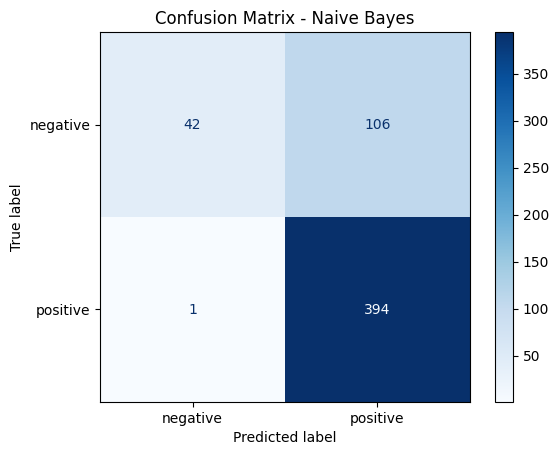

In [29]:
cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [30]:
print("The Naive Bayes model was able to classify reviews into positive and negative categories using TF-IDF features from cleaned review text.")
print("This shows that customer review text contains useful information for sentiment prediction.")

The Naive Bayes model was able to classify reviews into positive and negative categories using TF-IDF features from cleaned review text.
This shows that customer review text contains useful information for sentiment prediction.


## Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [32]:
lr_model = LogisticRegression(max_iter= 1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
lr_pred = lr_model.predict(X_test_tfidf)
lr_pred[:10]

array(['positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'positive', 'positive'],
      dtype=object)

In [34]:
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

Logistic Regression Accuracy: 0.8711


In [35]:
#Classification Report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.98      0.54      0.70       148
    positive       0.85      0.99      0.92       395

    accuracy                           0.87       543
   macro avg       0.91      0.77      0.81       543
weighted avg       0.89      0.87      0.86       543



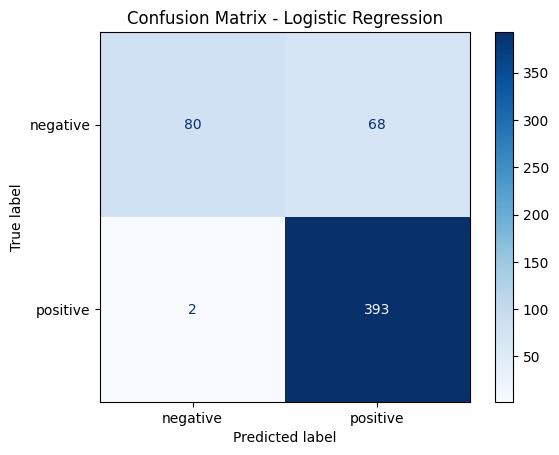

In [36]:
#Confusion Matrix

cm_lr = confusion_matrix(y_test, lr_pred, labels=["negative", "positive"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [37]:
#Comparing Naive Bayes and Logistic Regression
print("Model Comparison")
print("-------------------------")

print("Naive Bayes Accuracy:", round(accuracy, 4))
print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

Model Comparison
-------------------------
Naive Bayes Accuracy: 0.8029
Logistic Regression Accuracy: 0.8711


## Customer Segmentation(K-Means)

In [38]:
# Transform full dataset
X_all = tfidf.transform(df['clean_review'])

# Reduce dimensions (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all.toarray())

# KMeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca)

In [39]:
#Cluster Insights


for c in df['cluster'].unique():
    print("\nCluster", c)
    
    cluster_text = df[df['cluster'] == c]['clean_review']
    
    words = " ".join(cluster_text).split()
    top_words = pd.Series(words).value_counts().head(10)
    
    print(top_words)


Cluster 0
phone      1457
iphone     1058
battery     552
camera      457
apple       454
product     400
like        342
new         341
amazon      326
great       308
Name: count, dtype: int64

Cluster 1
good           105
product         27
quality          6
battery          5
one              5
iphone           3
sound            3
performance      3
phone            3
camera           3
Name: count, dtype: int64

Cluster 2
good         414
battery       87
phone         83
camera        83
quality       72
product       59
iphone        47
condition     38
life          35
display       27
Name: count, dtype: int64


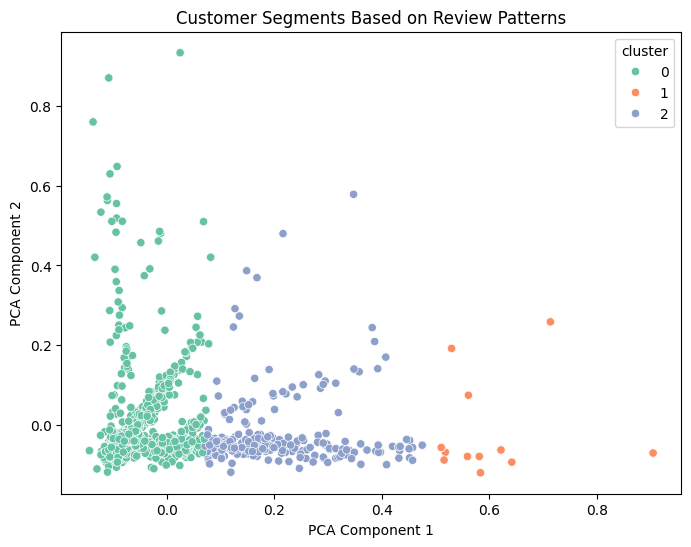

In [41]:
#Visualization
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=df['cluster'], palette='Set2')

plt.title("Customer Segments Based on Review Patterns")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

label
positive    1972
negative     742
Name: count, dtype: int64


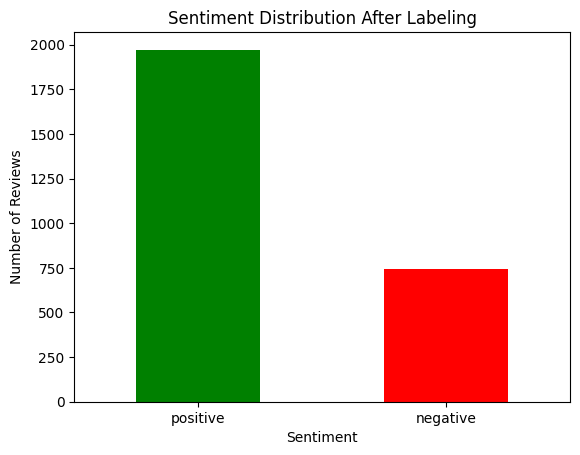

In [42]:
#Sentiment distribution after labeling
sentiment_counts = df["label"].value_counts()
print(sentiment_counts)
sentiment_counts.plot(kind="bar", color=["green", "red", "gray"])
plt.title("Sentiment Distribution After Labeling")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

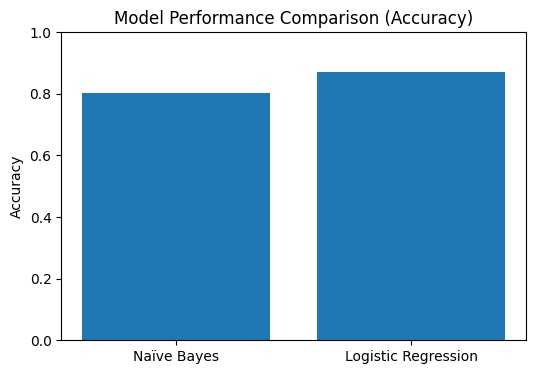

In [43]:
model_performance = pd.DataFrame({
    "Model": ["Naïve Bayes", "Logistic Regression"],
    "Accuracy": [0.8029, 0.8711]
})
plt.figure(figsize=(6,4))
plt.bar(model_performance["Model"], model_performance["Accuracy"])
plt.title("Model Performance Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

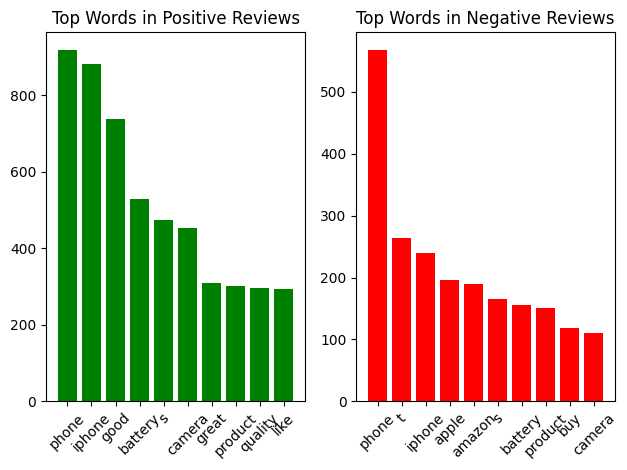

In [45]:
# most common words used in positive or negative reviews
positive_reviews = df [df["label"] == "positive"]["reviewDescription"]
negative_reviews = df[df["label"] == "negative"]["reviewDescription"]


from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words_clean(text_series, n=10):
    text = " ".join(text_series).lower()
    words = re.findall(r'\b[a-z]+\b', text)
    
    # Remove stopwords
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    
    return Counter(words).most_common(n)


top_positive_words = get_top_words_clean(positive_reviews, 10)
top_negative_words = get_top_words_clean(negative_reviews, 10)

pos_words, pos_counts = zip(*top_positive_words)
neg_words, neg_counts = zip(*top_negative_words)

plt.subplot(1,2,1)
plt.bar(pos_words, pos_counts, color="green")
plt.title("Top Words in Positive Reviews")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(neg_words, neg_counts, color="red")
plt.title("Top Words in Negative Reviews")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


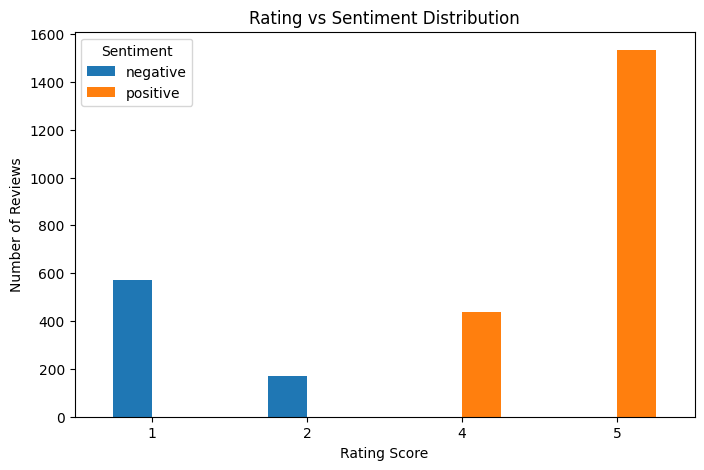

In [46]:
# Rating vs Sentiment Bar Chart

rating_sentiment = df.groupby(
    ["ratingScore", "label"]
).size().unstack(fill_value=0)

rating_sentiment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Rating vs Sentiment Distribution")
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()